In [12]:
# 安装额外的库
!pip install statsmodels filterpy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os

# 新增导入
from statsmodels.tsa.seasonal import seasonal_decompose
from filterpy.kalman import KalmanFilter # filterpy库中的KalmanFilter

# 设置设备 (GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")

import sympy
print(f"Sympy Version: {sympy.__version__}") # 确保 sympy 已正确加载
print(f"--- Setup Complete ---")

--- Environment Setup ---
Using device: cuda
PyTorch Version: 2.6.0+cu124
CUDA available. GPU: Tesla T4
PyTorch built with CUDA version: 12.4
Sympy Version: 1.13.1
--- Setup Complete ---


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
print(f"\n--- Data Loading and Initial Labeling ---")
DATA_FILE_COLAB_PATH = '/content/drive/MyDrive/data/realAdExchange/exchange-3_cpc_results.csv'
LABEL_FILE_COLAB_PATH = '/content/drive/MyDrive/labels/combined_windows.json'
JSON_KEY_FOR_LABELS = 'realAdExchange/exchange-3_cpc_results.csv'

data_df = None
try:
    data_df = pd.read_csv(DATA_FILE_COLAB_PATH)
    print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
    data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
    data_df = data_df.set_index('timestamp')
    print("Timestamp column processed and set as index.")
except Exception as e:
    print(f"Error during data loading or initial timestamp processing: {e}")

if data_df is not None:
    data_df['is_anomaly'] = 0
    parsed_anomaly_windows_count_initial = 0
    try:
        with open(LABEL_FILE_COLAB_PATH, 'r') as f:
            all_labels_json = json.load(f)
        raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])
        if raw_anomaly_windows_list:
            for window_event in raw_anomaly_windows_list:
                if isinstance(window_event, list) and len(window_event) == 2:
                    try:
                        start_ts = pd.to_datetime(window_event[0])
                        end_ts = pd.to_datetime(window_event[1])
                        anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                        data_df.loc[anomalous_points_mask, 'is_anomaly'] = 1
                        if anomalous_points_mask.sum() > 0:
                            parsed_anomaly_windows_count_initial += 1
                    except Exception as e_win:
                        print(f"  Warning: Could not process window event {window_event} for initial labeling: {e_win}")
            print(f"Initial label processing complete. Processed {parsed_anomaly_windows_count_initial} anomaly window(s).")
            print(f"Total data points initially marked as anomalous in data_df: {data_df['is_anomaly'].sum()}")
        else:
            print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}' for initial labeling.")
    except Exception as e_label:
        print(f"An error occurred during initial label processing: {e_label}")


else:
    print("data_df was not loaded successfully. Cannot proceed.")

print(f"--- Data Loading and Initial Labeling Complete ---")


--- Data Loading and Initial Labeling ---
Successfully loaded data from: /content/drive/MyDrive/data/realAdExchange/exchange-3_cpc_results.csv
Timestamp column processed and set as index.
Initial label processing complete. Processed 3 anomaly window(s).
Total data points initially marked as anomalous in data_df: 153
--- Data Loading and Initial Labeling Complete ---



--- Moving Average Preprocessing and Label Alignment ---
Applying Moving Average with window size: 10
Moving Average smoothing complete.
Smoothed data head (after NaN handling):
 timestamp
2011-07-01 00:15:01    0.080266
2011-07-01 01:15:01    0.080266
2011-07-01 02:15:01    0.080266
2011-07-01 03:15:01    0.080266
2011-07-01 04:15:01    0.080266
Name: value, dtype: float64


<ipython-input-15-c54132864461>:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_ma_smoothed = series_ma_smoothed.fillna(method='bfill')


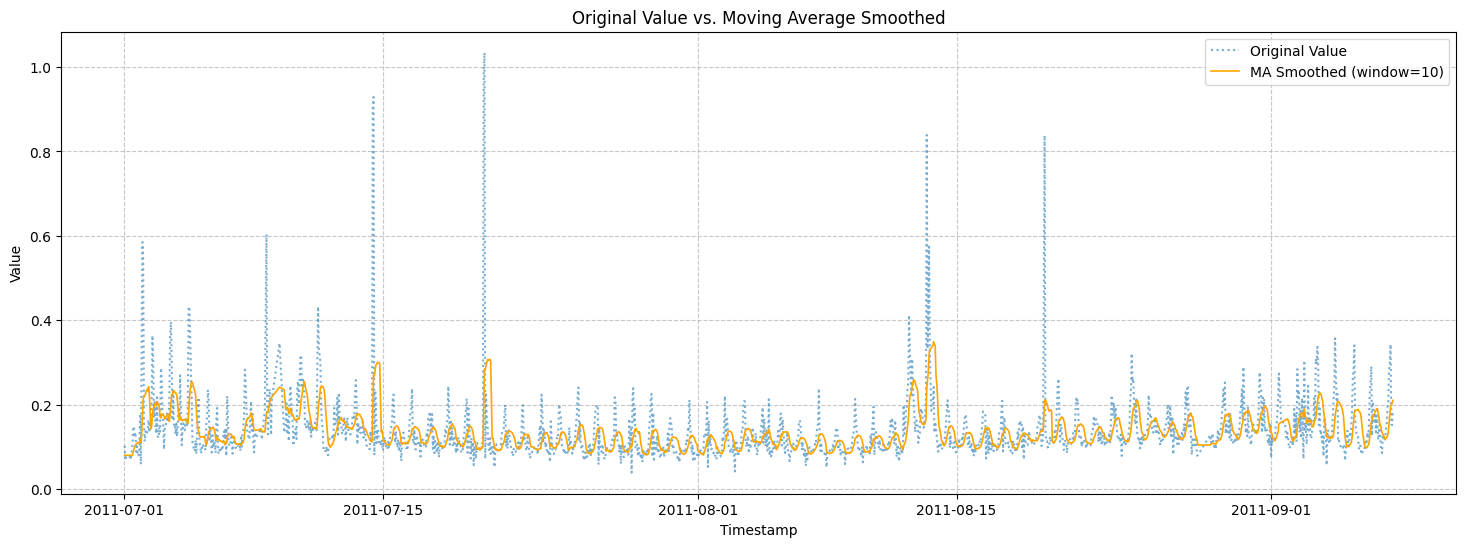

Labels are aligned with MA smoothed series (due to bfill keeping index).
Shape of time_series_for_lstm_raw (MA): (1538, 1)
Shape of true_labels_for_evaluation_aligned (MA): (1538,)
Sum of anomalies in aligned labels (MA): 153
--- Moving Average Preprocessing and Label Alignment Complete ---


In [15]:
print(f"\n--- Moving Average Preprocessing and Label Alignment ---")
time_series_for_lstm_raw = None
true_labels_for_evaluation_aligned = None

if data_df is not None and 'value' in data_df.columns:
    MA_WINDOW_SIZE = 10  # <<< 你可以调整这个窗口大小，例如 5, 10, 20, 50 等
    print(f"Applying Moving Average with window size: {MA_WINDOW_SIZE}")

    # 1. 计算移动平均
    # .rolling() 会在序列开头产生 (MA_WINDOW_SIZE - 1) 个NaN值
    # center=False 表示窗口的均值对应窗口的最后一个点
    series_ma_smoothed = data_df['value'].rolling(window=MA_WINDOW_SIZE, center=False).mean()

    # 2. 处理NaN值
    #    选项 A: 使用后一个有效值填充开头的NaN (保持序列长度和原始索引不变)
    series_ma_smoothed = series_ma_smoothed.fillna(method='bfill')
    #    选项 B: 也可以用前一个有效值填充 (如果bfill后还有NaN，通常不会)
    #    series_ma_smoothed = series_ma_smoothed.fillna(method='ffill')
    #    选项 C: 删除包含NaN的行 (会导致序列变短，需要更复杂的标签对齐)
    #    series_ma_smoothed_no_nan = series_ma_smoothed.dropna()
    #    aligned_index = series_ma_smoothed_no_nan.index
    #    series_ma_smoothed = series_ma_smoothed_no_nan # 更新

    print("Moving Average smoothing complete.")
    if series_ma_smoothed is not None:
        print("Smoothed data head (after NaN handling):\n", series_ma_smoothed.head())

        # 可选：绘制原始序列 vs MA平滑后序列
        plt.figure(figsize=(18, 6))
        plt.plot(data_df.index, data_df['value'], label='Original Value', alpha=0.6, linestyle=':')
        plt.plot(series_ma_smoothed.index, series_ma_smoothed, label=f'MA Smoothed (window={MA_WINDOW_SIZE})', color='orange', linewidth=1.2)
        plt.title("Original Value vs. Moving Average Smoothed")
        plt.xlabel("Timestamp")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        # 3. 准备用于LSTM的序列
        time_series_for_lstm_raw = series_ma_smoothed.values.reshape(-1, 1)

        # 4. 对齐真实异常标签
        # 如果使用了 fillna(method='bfill')，series_ma_smoothed 的索引应该与 data_df.index 相同
        # 因此，可以直接使用 data_df['is_anomaly']
        if 'is_anomaly' in data_df.columns and data_df.index.equals(series_ma_smoothed.index):
            true_labels_for_evaluation_aligned = data_df['is_anomaly'].values
            print(f"Labels are aligned with MA smoothed series (due to bfill keeping index).")
        elif 'is_anomaly' in data_df.columns: # 如果索引可能发生变化 (例如用了dropna)
            print("Aligning labels to the index of the MA smoothed series (if different)...")
            # 确保对齐，以防万一索引有变或部分数据被舍弃
            original_anomaly_labels_series = pd.Series(data_df['is_anomaly'].values, index=data_df.index)
            aligned_labels = original_anomaly_labels_series.reindex(series_ma_smoothed.index, method='nearest').fillna(0)
            true_labels_for_evaluation_aligned = aligned_labels.astype(int).to_numpy()

        if true_labels_for_evaluation_aligned is not None:
            print(f"Shape of time_series_for_lstm_raw (MA): {time_series_for_lstm_raw.shape}")
            print(f"Shape of true_labels_for_evaluation_aligned (MA): {true_labels_for_evaluation_aligned.shape}")
            print(f"Sum of anomalies in aligned labels (MA): {true_labels_for_evaluation_aligned.sum()}")
        else:
            print("Could not prepare aligned labels.")
            true_labels_for_evaluation_aligned = np.zeros(len(time_series_for_lstm_raw)) # Fallback
    else:
        print("Moving Average smoothing resulted in no data.")

else:
    print("data_df or 'value' column not available for Moving Average preprocessing.")

print(f"--- Moving Average Preprocessing and Label Alignment Complete ---")

In [16]:
print(f"\n--- LSTM Data Preprocessing (on MA Output) ---")
# 确保 time_series_for_lstm_raw 和 true_labels_for_evaluation_aligned 已成功生成
if 'time_series_for_lstm_raw' in locals() and time_series_for_lstm_raw is not None and \
   'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None and \
   len(time_series_for_lstm_raw) > 0:

    scaler = MinMaxScaler(feature_range=(-1, 1))
    time_series_scaled = scaler.fit_transform(time_series_for_lstm_raw) # 使用MA平滑后的数据
    print(f"Data scaled. Shape: {time_series_scaled.shape}")

    SEQUENCE_LENGTH = 30

    def create_sequences_colab(input_data, sequence_length):
        sequences = []
        for i in range(len(input_data) - sequence_length + 1):
            seq = input_data[i:(i + sequence_length)]
            sequences.append(seq)
        return np.array(sequences)

    X_sequences = create_sequences_colab(time_series_scaled, SEQUENCE_LENGTH)
    X_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)

    print(f"Created sequences. X_tensor shape: {X_tensor.shape}, y_tensor shape: {y_tensor.shape}")

    BATCH_SIZE = 32
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"DataLoader created with batch size {BATCH_SIZE}.")
else:
    print("Skipping LSTM data preprocessing as input data from MA step is not available or empty.")

print(f"--- LSTM Data Preprocessing Complete ---")


--- LSTM Data Preprocessing (on MA Output) ---
Data scaled. Shape: (1538, 1)
Created sequences. X_tensor shape: torch.Size([1509, 30, 1]), y_tensor shape: torch.Size([1509, 30, 1])
DataLoader created with batch size 32.
--- LSTM Data Preprocessing Complete ---


In [17]:
print(f"\n--- LSTM Autoencoder Model Definition ---")
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMAutoencoder, self).__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim, # 可以选择不同的解码器隐藏层大小
            num_layers=num_layers,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        encoder_outputs, (hidden, cell) = self.encoder_lstm(x)
        # 使用编码器的输出（所有时间步）作为解码器的输入
        decoder_outputs, _ = self.decoder_lstm(encoder_outputs, (hidden, cell))
        reconstructed_x = self.output_layer(decoder_outputs)
        return reconstructed_x

# 模型参数
INPUT_DIM = 1  # 单变量时间序列
HIDDEN_DIM = 64 # LSTM隐藏单元数量 (可调)
NUM_LAYERS = 2  # LSTM层数 (可调)

if 'X_tensor' in locals(): # 确保模型可以被实例化
    model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
    print(model)
    print(f"Model instantiated and moved to device: {next(model.parameters()).device}")
else:
    print("Cannot instantiate model as X_tensor is not available.")
print(f"--- Model Definition Complete ---")


--- LSTM Autoencoder Model Definition ---
LSTMAutoencoder(
  (encoder_lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (decoder_lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
Model instantiated and moved to device: cuda:0
--- Model Definition Complete ---



--- Model Training ---
Starting training for 30 epochs...
Epoch [5/30], Loss: 0.004514
Epoch [10/30], Loss: 0.000207
Epoch [15/30], Loss: 0.000051
Epoch [20/30], Loss: 0.000072
Epoch [25/30], Loss: 0.000018
Epoch [30/30], Loss: 0.000076
Training finished.


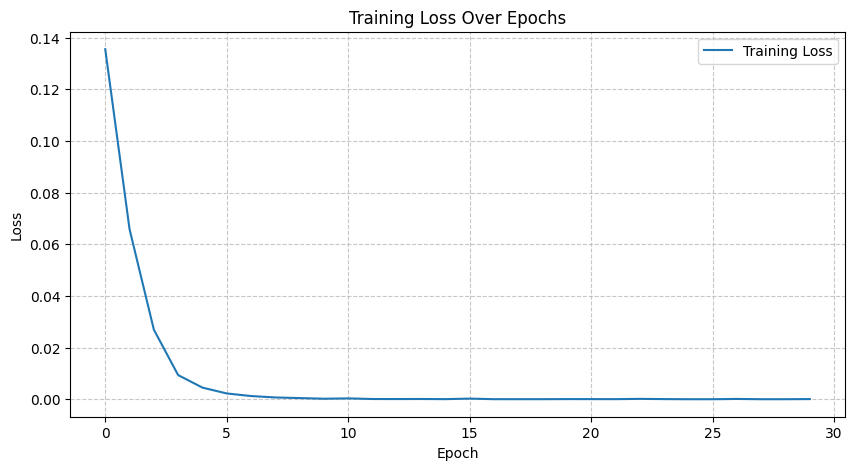

--- Model Training Complete ---


In [18]:
print(f"\n--- Model Training ---")
if 'model' in locals() and 'dataloader' in locals(): # 确保模型和数据加载器已准备好
    NUM_EPOCHS = 30  # 可根据需要调整
    LEARNING_RATE = 0.001

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # 之前本地环境出错的地方

    history = {'train_loss': []}
    print(f"Starting training for {NUM_EPOCHS} epochs...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        for seq_in, seq_target in dataloader:
            # 数据已经在创建 DataLoader 时移到了 device
            # seq_in, seq_target = seq_in.to(device), seq_target.to(device)

            optimizer.zero_grad()
            seq_pred = model(seq_in)
            loss = criterion(seq_pred, seq_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_epoch_loss:.6f}")
    print("Training finished.")

    # 可视化训练损失
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Skipping model training as model or dataloader is not available.")
print(f"--- Model Training Complete ---")

In [19]:
print(f"\n--- Anomaly Score Calculation (on MA Output) ---")
# 确保模型和 X_tensor (来自MA平滑后的数据) 已准备好
if 'model' in locals() and 'X_tensor' in locals() and 'criterion' in locals() and 'SEQUENCE_LENGTH' in locals() and 'time_series_scaled' in locals() :
    model.eval()
    reconstruction_errors_per_sequence = []

    with torch.no_grad():
        for i in range(X_tensor.size(0)):
            seq_true_single = X_tensor[i:i+1]
            seq_pred_single = model(seq_true_single)
            error = criterion(seq_pred_single, seq_true_single).item()
            reconstruction_errors_per_sequence.append(error)

    reconstruction_errors_per_sequence = np.array(reconstruction_errors_per_sequence)
    print(f"Calculated reconstruction errors for {len(reconstruction_errors_per_sequence)} sequences (from MA output).")

    # 将序列的重构误差映射回原始时间序列的每个点 (相对于MA处理后的时间轴)
    anomaly_scores_ma = np.full(len(time_series_scaled), np.nan)  # 重命名变量
    for i in range(len(reconstruction_errors_per_sequence)):
        anomaly_scores_ma[i + SEQUENCE_LENGTH - 1] = reconstruction_errors_per_sequence[i]

    first_valid_score_idx_ma = np.where(~np.isnan(anomaly_scores_ma))[0]
    if len(first_valid_score_idx_ma) > 0:
        anomaly_scores_ma[:first_valid_score_idx_ma[0]] = anomaly_scores_ma[first_valid_score_idx_ma[0]]
    else:
        anomaly_scores_ma[:] = 0

    print("Anomaly scores (from MA output) mapped to respective time points.")
else:
    print("Skipping anomaly score calculation as prerequisites are not met.")
    anomaly_scores_ma = None

print(f"--- Anomaly Score Calculation (on MA Output) Complete ---")


--- Anomaly Score Calculation (on MA Output) ---
Calculated reconstruction errors for 1509 sequences (from MA output).
Anomaly scores (from MA output) mapped to respective time points.
--- Anomaly Score Calculation (on MA Output) Complete ---


In [20]:
print(f"\n--- Thresholding and Evaluation (with MA Preprocessing) ---")
# 确保 anomaly_scores_ma 和 true_labels_for_evaluation_aligned 已准备好
if 'anomaly_scores_ma' in locals() and anomaly_scores_ma is not None and \
   'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None:

    valid_indices_for_eval_ma = ~np.isnan(anomaly_scores_ma)

    if len(anomaly_scores_ma) == len(true_labels_for_evaluation_aligned):
        eval_scores_ma = anomaly_scores_ma[valid_indices_for_eval_ma]
        eval_true_labels_ma = true_labels_for_evaluation_aligned[valid_indices_for_eval_ma]

        if len(eval_scores_ma) > 0 and len(eval_true_labels_ma) > 0:
            threshold_ma = np.quantile(eval_scores_ma, 0.95)
            print(f"Anomaly threshold (on MA scores, 95th percentile): {threshold_ma:.6f}")

            predicted_anomalies_bool_ma = eval_scores_ma > threshold_ma
            predicted_anomalies_int_ma = predicted_anomalies_bool_ma.astype(int)

            precision, recall, f1, _ = precision_recall_fscore_support(eval_true_labels_ma, predicted_anomalies_int_ma, average='binary', zero_division=0)
            cm = confusion_matrix(eval_true_labels_ma, predicted_anomalies_int_ma)

            print(f"Evaluation Results (on MA preprocessed data):")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}") # <<< 这是你关心的F1分数
            print(f"  Confusion Matrix:\n{cm}")
        else:
            print("Not enough data for evaluation after NaN removal (MA scores).")
    else:
        print(f"Error: Length mismatch between anomaly_scores_ma ({len(anomaly_scores_ma)}) and true_labels_for_evaluation_aligned ({len(true_labels_for_evaluation_aligned)}). Cannot evaluate.")
else:
    print("Skipping thresholding and evaluation as 'anomaly_scores_ma' or 'true_labels_for_evaluation_aligned' is not available.")
print(f"--- Thresholding and Evaluation (with MA Preprocessing) Complete ---")


--- Thresholding and Evaluation (with MA Preprocessing) ---
Anomaly threshold (on MA scores, 95th percentile): 0.000091
Evaluation Results (on MA preprocessed data):
  Precision: 0.2987
  Recall:    0.1503
  F1-Score:  0.2000
  Confusion Matrix:
[[1331   54]
 [ 130   23]]
--- Thresholding and Evaluation (with MA Preprocessing) Complete ---



--- Final Visualization (with MA Preprocessing) ---


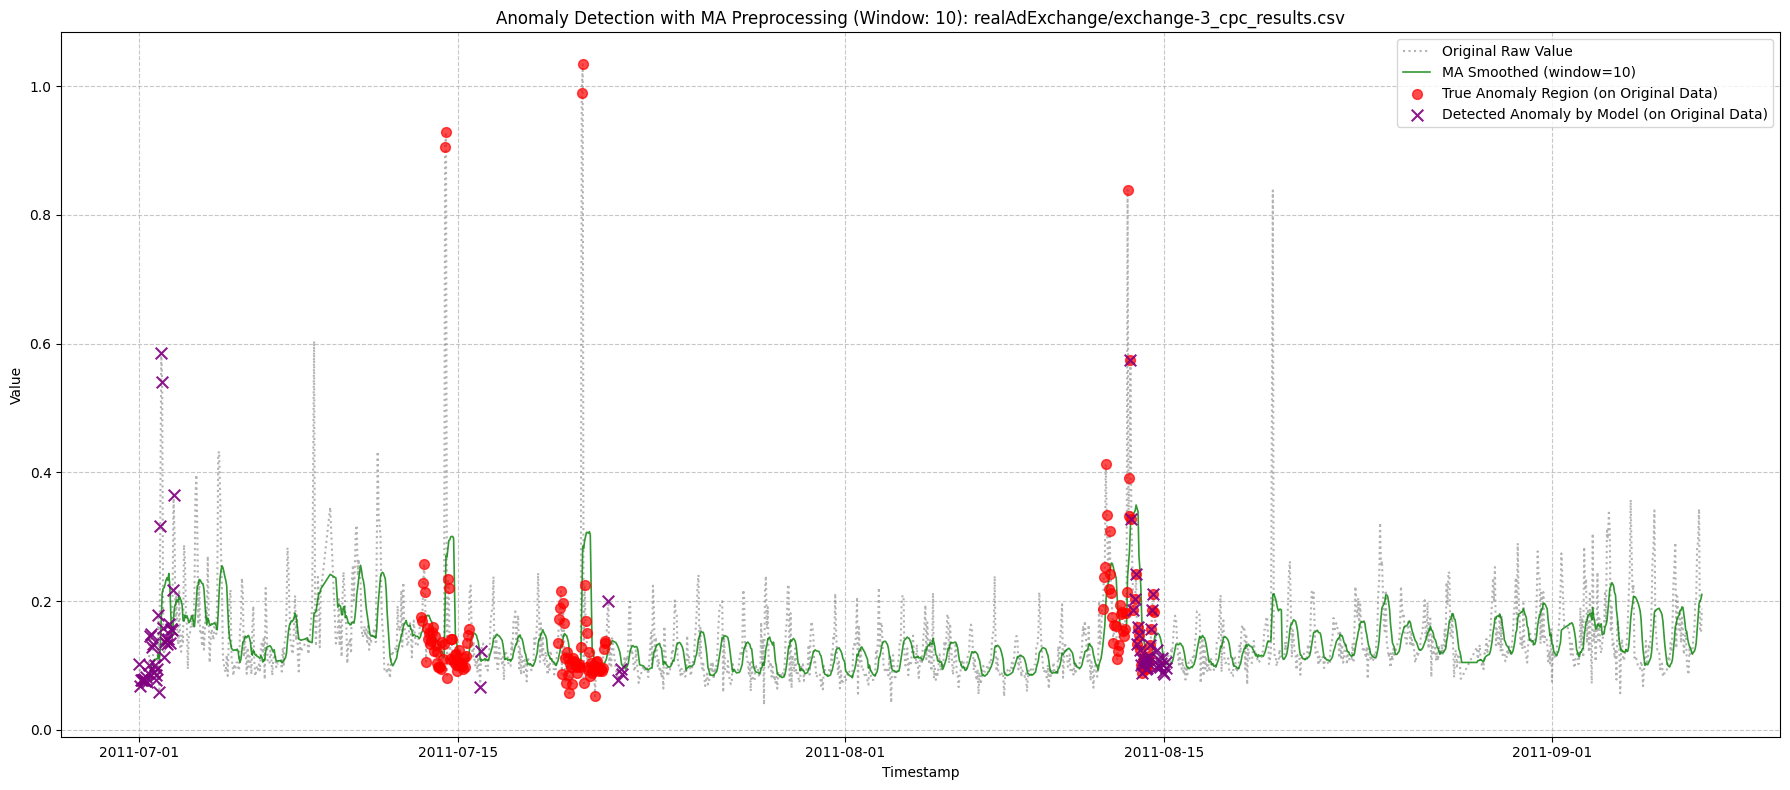

--- Visualization (with MA Preprocessing) Complete ---


In [21]:
print(f"\n--- Final Visualization (with MA Preprocessing) ---")
if ('data_df' in locals() and data_df is not None and
    'series_ma_smoothed' in locals() and series_ma_smoothed is not None and # MA平滑后的序列
    'anomaly_scores_ma' in locals() and anomaly_scores_ma is not None and
    'threshold_ma' in locals() and
    'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None):

    plt.figure(figsize=(18, 8))

    # 1. 绘制原始数据
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='gray', alpha=0.6, linestyle=':')

    # 2. 绘制MA平滑后的数据
    plt.plot(series_ma_smoothed.index, series_ma_smoothed, label=f'MA Smoothed (window={MA_WINDOW_SIZE})', color='green', linewidth=1.2, alpha=0.8)

    # 3. 标记真实异常区域 (基于原始 data_df 的 is_anomaly)
    true_anomalies_plot_df = data_df[data_df['is_anomaly'] == 1]
    if not true_anomalies_plot_df.empty:
        plt.scatter(true_anomalies_plot_df.index,
                    true_anomalies_plot_df['value'],
                    color='red', label='True Anomaly Region (on Original Data)', marker='o', s=50, alpha=0.7, zorder=3)

    # 4. 标记模型检测到的异常点
    # predicted_anomalies_on_ma_timeline 是在 series_ma_smoothed 的时间轴上的预测 (0 或 1)
    predicted_anomalies_on_ma_timeline = np.zeros_like(anomaly_scores_ma, dtype=int)
    if 'predicted_anomalies_bool_ma' in locals() and 'valid_indices_for_eval_ma' in locals():
        predicted_anomalies_on_ma_timeline[valid_indices_for_eval_ma] = predicted_anomalies_bool_ma.astype(int)

    # 获取检测到异常的时间戳 (这些时间戳来自 series_ma_smoothed.index)
    detected_anomaly_timestamps_ma = series_ma_smoothed.index[predicted_anomalies_on_ma_timeline == 1]

    if len(detected_anomaly_timestamps_ma) > 0:
        # 为了在图上清晰显示，我们可以在原始数据上标记这些点
        # 由于 series_ma_smoothed 和 data_df (如果使用bfill) 应该有相同的索引，可以直接用
        values_at_detected_anomalies = data_df['value'].loc[detected_anomaly_timestamps_ma]
        plt.scatter(detected_anomaly_timestamps_ma,
                    values_at_detected_anomalies,
                    color='purple', label='Detected Anomaly by Model (on Original Data)', marker='x', s=70, alpha=0.9, zorder=4)

    plt.title(f"Anomaly Detection with MA Preprocessing (Window: {MA_WINDOW_SIZE}): {JSON_KEY_FOR_LABELS}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping final visualization as prerequisites are not met.")
print(f"--- Visualization (with MA Preprocessing) Complete ---")